In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers

In [28]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

print("Original Shape :", x_train.shape)

Original Shape : (60000, 28, 28)


In [29]:
x_train = x_train.astype("float32")

x_train = (x_train - 127.5) / 127.5

x_train = np.expand_dims(x_train, axis=-1)

print("Processed Shape :", x_train.shape)

Processed Shape : (60000, 28, 28, 1)


pipline

In [4]:
BATCH_SIZE = 256
BUFFER_SIZE = 60000

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)

train_dataset = train_dataset.shuffle(BUFFER_SIZE)

train_dataset = train_dataset.batch(BATCH_SIZE)

generator model

In [5]:
def build_generator():

    model = tf.keras.Sequential()

    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    model.add(
        layers.Conv2DTranspose(
            128,
            (5, 5),
            strides=(1, 1),
            padding="same",
            use_bias=False,
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            64,
            (5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False,
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            1,
            (5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False,
            activation="tanh",
        )
    )

    return model

In [6]:
generator = build_generator()

generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

discriminator model

In [7]:
def build_discriminator():

    model = tf.keras.Sequential()

    model.add(
        layers.Conv2D(
            64,
            (5, 5),
            strides=(2, 2),
            padding="same",
            input_shape=(28, 28, 1),
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(
        layers.Conv2D(
            128,
            (5, 5),
            strides=(2, 2),
            padding="same",
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())

    model.add(layers.Dense(1))

    return model

In [8]:
discriminator = build_discriminator()

discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

loss function

In [9]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

generator loss

In [10]:
def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

discriminator loss

In [11]:
def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss

optimizers

In [12]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

noise dimension

In [13]:
noise_dim = 100

num_examples_to_generate = 16

seed = tf.random.normal(
    [num_examples_to_generate, noise_dim]
)

In [14]:
@tf.function
def train_step(images):

    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)

        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

save image

In [15]:
def save_images(model, epoch, test_input):

    predictions = model(
        test_input,
        training=False
    )

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            predictions[i, :, :, 0] * 127.5 + 127.5,
            cmap="gray"
        )

        plt.axis("off")

    plt.savefig(
        os.path.join(
            save_folder,
            f"epoch_{epoch:03d}.png"
        )
    )

    plt.close(fig)

In [16]:
def train(dataset, epochs):

    for epoch in range(epochs):

        gen_loss = 0
        disc_loss = 0

        for image_batch in dataset:

            gen_loss, disc_loss = train_step(image_batch)

        save_images(generator, epoch + 1, seed)

        print(
            "Epoch {:03d} | Generator Loss: {:.4f} | Discriminator Loss: {:.4f}".format(
                epoch + 1,
                float(gen_loss),
                float(disc_loss)
            )
        )

    print("\nTraining Completed.")

In [17]:
EPOCHS = 50

train(train_dataset, EPOCHS)

Epoch 001 | Generator Loss: 0.6840 | Discriminator Loss: 1.3623
Epoch 002 | Generator Loss: 0.8234 | Discriminator Loss: 1.1633
Epoch 003 | Generator Loss: 0.7466 | Discriminator Loss: 1.3799
Epoch 004 | Generator Loss: 0.5783 | Discriminator Loss: 1.3931
Epoch 005 | Generator Loss: 0.7378 | Discriminator Loss: 1.2664
Epoch 006 | Generator Loss: 0.7507 | Discriminator Loss: 1.2053
Epoch 007 | Generator Loss: 0.9157 | Discriminator Loss: 1.1375
Epoch 008 | Generator Loss: 0.8836 | Discriminator Loss: 1.3075
Epoch 009 | Generator Loss: 0.8986 | Discriminator Loss: 1.2786
Epoch 010 | Generator Loss: 0.7946 | Discriminator Loss: 1.2516
Epoch 011 | Generator Loss: 0.7425 | Discriminator Loss: 1.3147
Epoch 012 | Generator Loss: 0.6930 | Discriminator Loss: 1.3368
Epoch 013 | Generator Loss: 0.8431 | Discriminator Loss: 1.3013
Epoch 014 | Generator Loss: 0.7209 | Discriminator Loss: 1.3134
Epoch 015 | Generator Loss: 0.7684 | Discriminator Loss: 1.4442
Epoch 016 | Generator Loss: 0.6844 | Dis

In [19]:
noise = tf.random.normal([16, noise_dim])

generated_images = generator(noise, training=False)

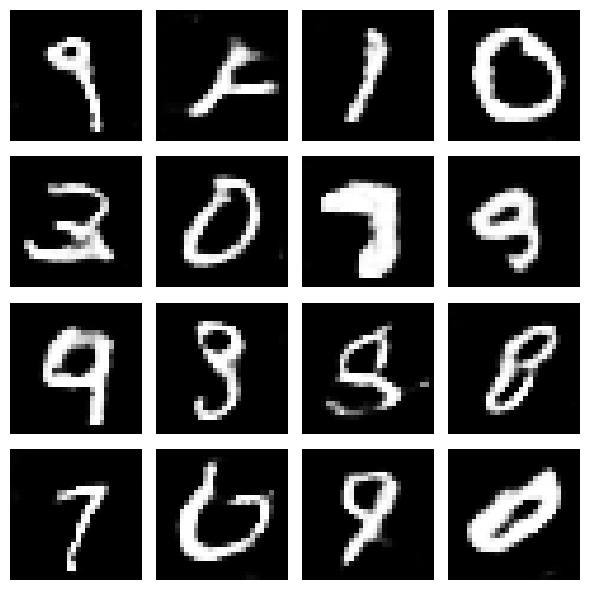

In [20]:
plt.figure(figsize=(6, 6))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    image = generated_images[i, :, :, 0]

    image = image * 127.5 + 127.5

    plt.imshow(image, cmap="gray")

    plt.axis("off")

plt.tight_layout()

plt.show()

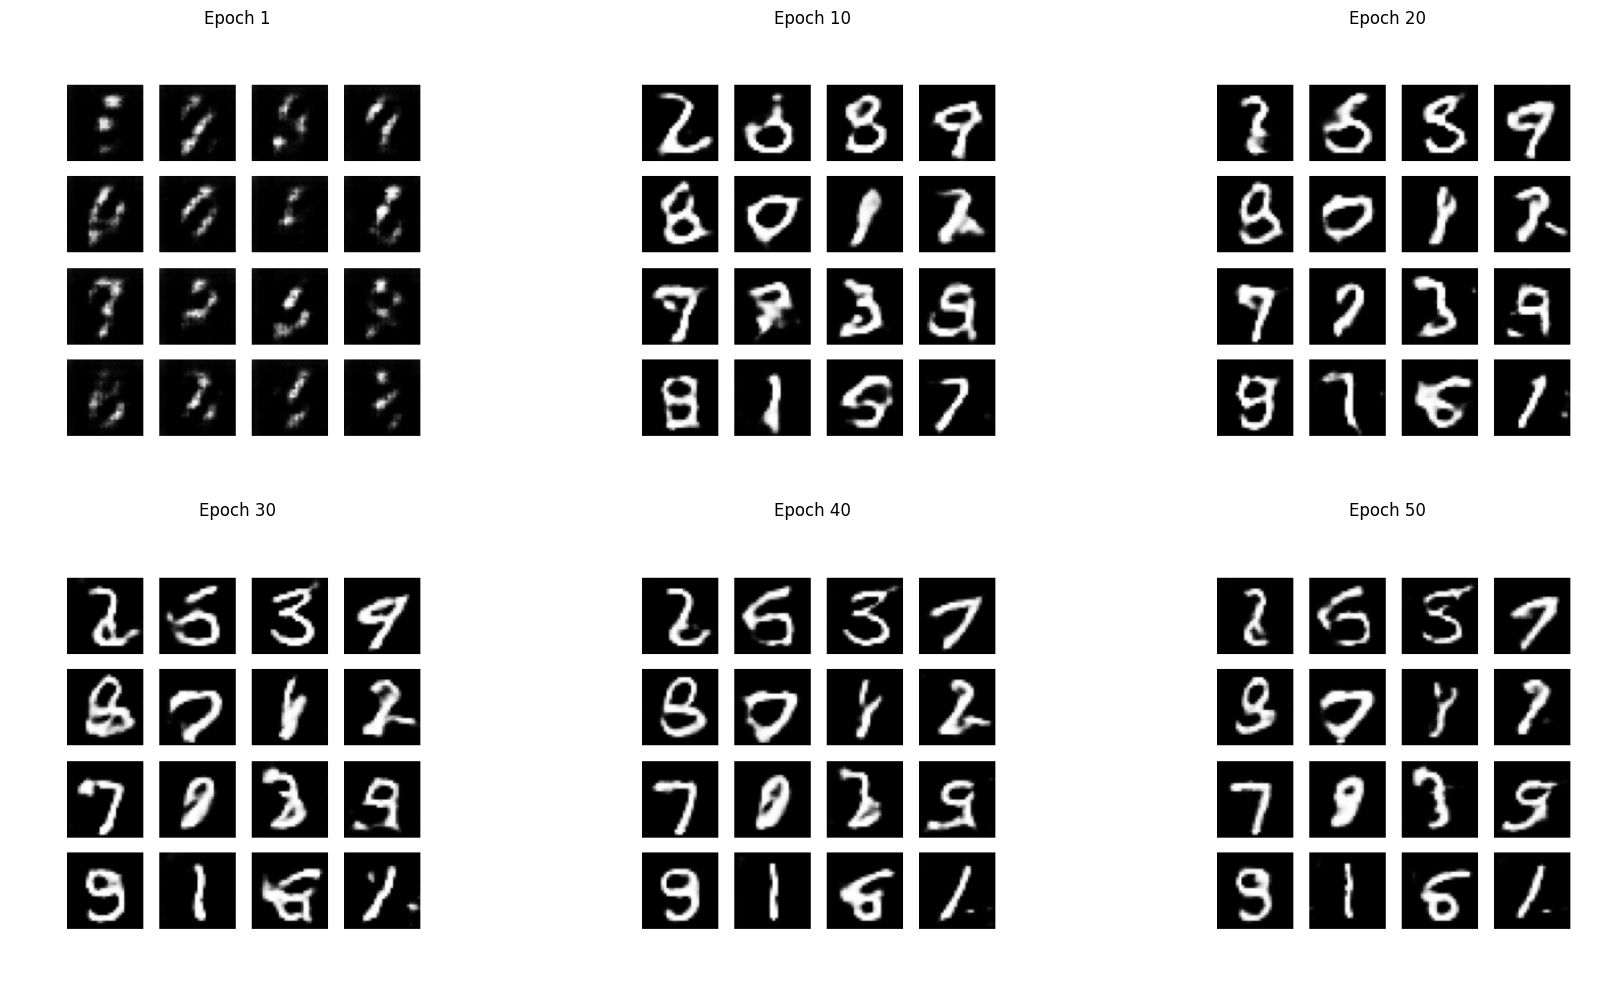

In [21]:
epochs_to_compare = [1, 10, 20, 30, 40, 50]

plt.figure(figsize=(18, 10))

for i, epoch in enumerate(epochs_to_compare):

    image = plt.imread(f"{save_folder}/epoch_{epoch:03d}.png")

    plt.subplot(2, 3, i + 1)

    plt.imshow(image)

    plt.title(f"Epoch {epoch}")

    plt.axis("off")

plt.tight_layout()

plt.show()